In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the data
df = pd.read_csv("../data/raw_data/nigeria.csv") # Ensure you put your CSV in the data/ folder!

# 1. Immediate Clean: Replace NASA's -999 sentinel with NaN [cite: 114]
df.replace(-999, np.nan, inplace=True)

# 2. Date Conversion: Turn YEAR and DOY into a real date [cite: 111]
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month # Needed for seasonal analysis [cite: 112]

# 3. Add Country Column [cite: 110]
df['Country'] = 'Nigeria'

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,2015-01-01,1,Sudan
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,2015-01-02,1,Sudan
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,2015-01-03,1,Sudan
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,2015-01-04,1,Sudan
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,2015-01-05,1,Sudan


In [14]:
###Data cleaning (sentinels and duplicates
            
# 1. Replace NASA's -999 sentinel with NaN [cite: 114, 398]
df.replace(-999, np.nan, inplace=True)

# 2. Handle duplicates [cite: 116]
duplicate_count = df.duplicated().sum()
print(f"Duplicates found: {duplicate_count}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report [cite: 118]
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct[missing_pct > 0])

Duplicates found: 0

Missing Values Percentage:
Series([], dtype: float64)


In [8]:
###statistical profiling

# Summary statistics for numeric columns [cite: 117]
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


In [15]:
### Outlier detection( z-scores)

# Flag rows where |Z| > 3 for key climate variables [cite: 121]
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
outlier_report = {}

for col in cols_to_check:
    z_scores = np.abs(stats.zscore(df[col], nan_policy='omit'))
    outlier_report[col] = (z_scores > 3).sum()

print("Outlier counts (|Z| > 3):")
print(outlier_report)

# Handling strategy: We retain outliers as they often represent 
# actual extreme weather events critical for COP32[cite: 123].

Outlier counts (|Z| > 3):
{'T2M': np.int64(10), 'T2M_MAX': np.int64(1), 'T2M_MIN': np.int64(68), 'PRECTOTCORR': np.int64(75), 'RH2M': np.int64(128), 'WS2M': np.int64(5)}


<BarContainer object of 135 artists>

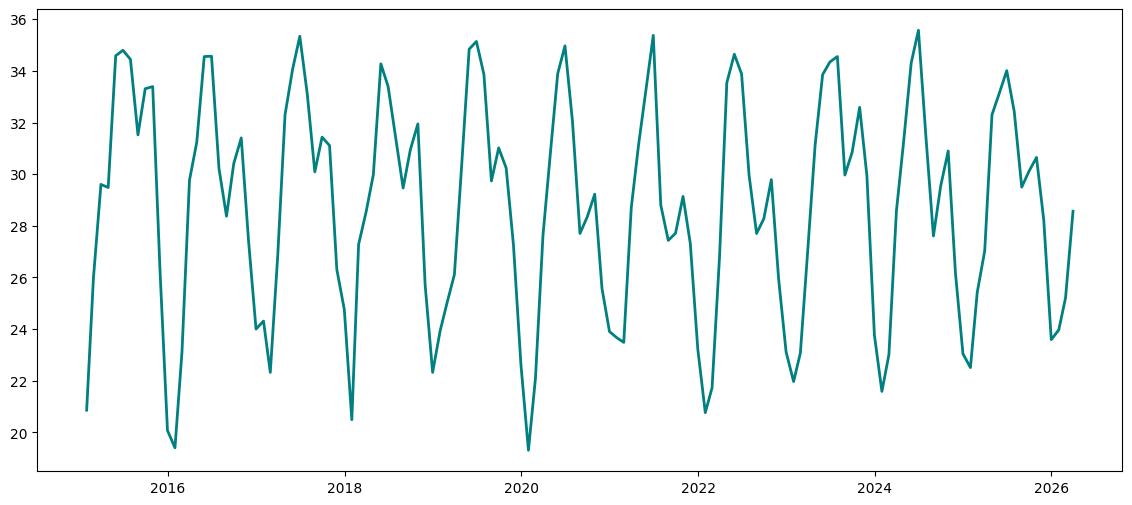

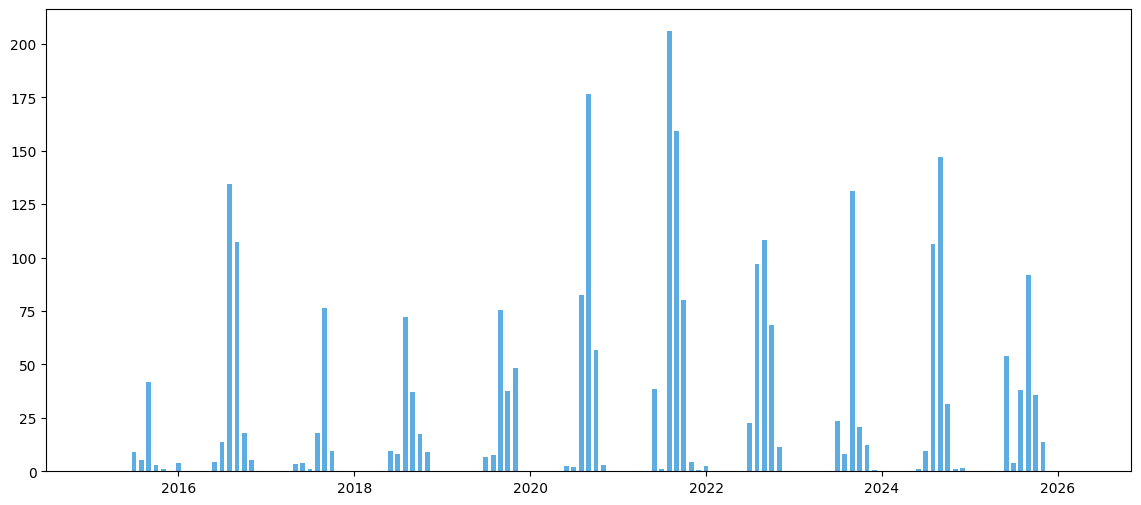

In [12]:
### Time series analysis
# 1. Plot monthly average Temperature (T2M)
plt.figure(figsize=(14, 6))

# Change 'M' to 'ME' (Month End)
monthly_temp = df.set_index('Date')['T2M'].resample('ME').mean() 

plt.plot(monthly_temp.index, monthly_temp.values, color='teal', linewidth=2)

# ... (the rest of your plotting code)

# 2. Plot monthly total Precipitation (PRECTOTCORR)
plt.figure(figsize=(14, 6))
# Change 'M' to 'ME' here as well
monthly_precip = df.set_index('Date')['PRECTOTCORR'].resample('ME').sum()
plt.bar(monthly_precip.index, monthly_precip.values, width=20, color='#3498db', alpha=0.8)
# ... (the rest of your plotting code)

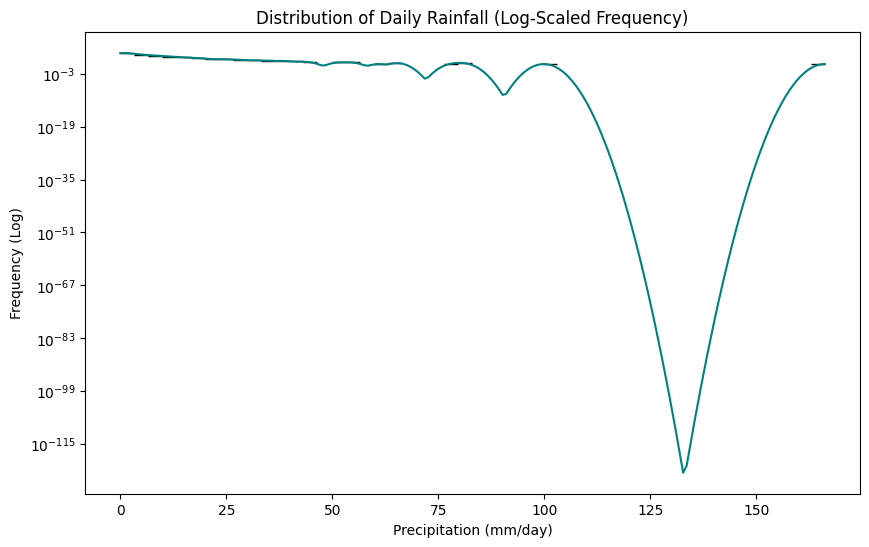

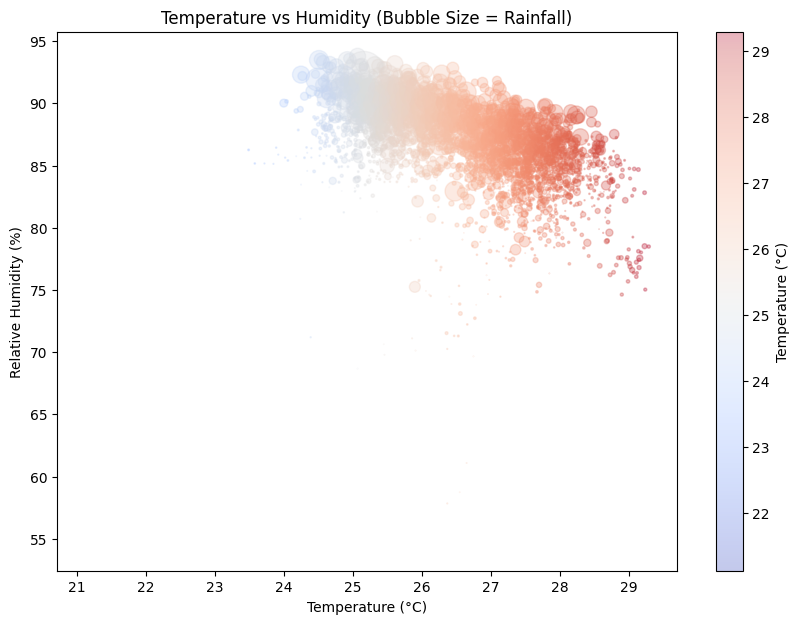

In [16]:
### distribution analysis 

# 1. Histogram of Precipitation (using log scale as suggested for skewed data) 
plt.figure(figsize=(10, 6))
import seaborn as sns # Standard alias
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='teal', log_scale=(False, True))
plt.title("Distribution of Daily Rainfall (Log-Scaled Frequency)", fontsize=12)
plt.xlabel("Precipitation (mm/day)")
plt.ylabel("Frequency (Log)")
plt.show()

# 2. Bubble Chart: T2M vs. RH2M (Relative Humidity) [cite: 137]
# Size of the bubble represents the amount of rainfall (PRECTOTCORR)
plt.figure(figsize=(10, 7))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.3, c=df['T2M'], cmap='coolwarm')
plt.colorbar(label='Temperature (°C)')
plt.title("Temperature vs Humidity (Bubble Size = Rainfall)", fontsize=12)
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.show()

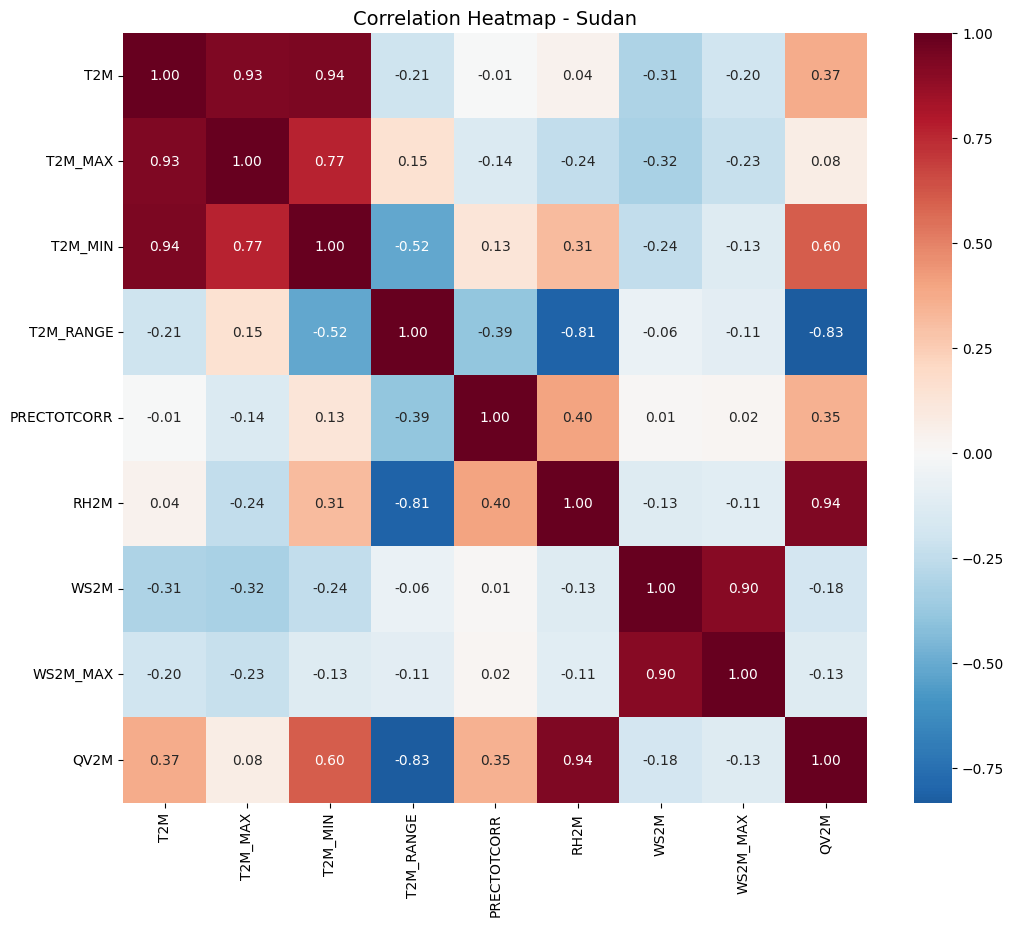

In [10]:
###Correlation analysis

# Create a correlation heatmap [cite: 132]
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation
cols = ['T2M', 'T2M_MAX', 'T2M_MIN'
, 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'QV2M']
correlation_matrix = df[cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title(f"Correlation Heatmap - {df['Country'].iloc[0]}", fontsize=14)
plt.show()

In [17]:
# Create the clean filename based on the country
country_name = "nigeria" # Update this for each notebook
output_path = f"../data/cleaned_data/nigeria_clean.csv"

# Export to the data folder
df.to_csv(output_path, index=False)
print(f"Successfully saved)")



Successfully saved)
